In [1]:
!pip install torch torcheeg python-picard

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.4/251.4 kB 5.0 MB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.5/231.5 kB 11.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of mne to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of wfdb to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 66.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 55.2 MB/s eta 0:00:00:00:0100:01

In [2]:
# pip install mne

In [2]:
import mne
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import torch 
import torcheeg
from torcheeg import datasets
from torcheeg import transforms
from torch.utils.data import Dataset

In [3]:
emotion_mapping = {
    (0, 0): "Boring",  # Low arousal, Low valence
    (0, 1): "Calm",    # Low arousal, High valence
    
    (1, 0): "Horror",  # High arousal, Low valence    
    (1, 1): "Funny"    # High arousal, High valence
}

In [4]:
def fastica_symmetric(X, n_components=None, tol=1e-5, max_iter=200, function='logcosh', alpha=1.0):
    """
    Perform Independent Component Analysis (ICA) using the symmetric FastICA algorithm.

    This function implements a symmetric version of the FastICA algorithm based on
    a fixed-point iteration scheme. The algorithm first centers and whitens the input
    data, and then iteratively estimates the independent components using a chosen
    nonlinearity.

    Parameters:
        X (torch.Tensor): Input data tensor with shape (n_samples, n_features). Each
            row corresponds to a sample, and each column corresponds to an observed mixed signal.
        n_components (int, optional): Number of independent components to extract.
            Defaults to None, in which case it is set to the number of features in X.
        tol (float, optional): Tolerance for the convergence criterion. The algorithm
            stops when the maximum absolute change in the weight vectors (in terms of
            their dot-product convergence) falls below this threshold. Default is 1e-5.
        max_iter (int, optional): Maximum number of iterations allowed for the fixed-point
            update process. Defaults to 200.
        function (str, optional): Nonlinearity used in the fixed-point iteration.
            Supported options are 'logcosh' and 'exp'. The 'logcosh' function uses
            a hyperbolic tangent nonlinearity with scaling by alpha, while 'exp'
            applies an exponential damping function. Default is 'logcosh'.
        alpha (float, optional): Parameter for scaling the nonlinearity in the 'logcosh'
            function. Defaults to 1.0.

    Returns:
        S (torch.Tensor): Estimated source signals (independent components) of shape
            (n_samples, n_components). This is computed using the unmixing matrix applied
            to the centered data.
        mixing (torch.Tensor): Estimated mixing matrix of shape (n_features, n_components).
            This is computed as the pseudo-inverse of the unmixing matrix.
        unmixing (torch.Tensor): Estimated unmixing matrix of shape (n_components, n_features)
            such that when applied to the centered data, the independent components are obtained.

    Notes:
        - The input data is centered and whitened prior to the estimation of independent
          components. Whitening is performed using eigenvalue decomposition of the covariance
          matrix.
        - The algorithm initializes the weight matrix with random orthogonal vectors.
        - The fixed-point iteration involves projecting the whitened data onto the weight vectors,
          applying the nonlinearity elementwise, and then updating the weights.
        - A symmetric decorrelation step is performed at each iteration to ensure that all estimated
          components remain orthogonal.
        - Convergence is evaluated by comparing the dot products between the updated and previous
          weight vectors.
        - In the current implementation, the 'exp' nonlinearity branch appears twice and performs the
          same operation; ensure that the correct nonlinearity is chosen by the user.
        - A ValueError is raised if the provided nonlinearity is not supported.

    Example:
        >>> import torch
        >>> # Generate some synthetic data (n_samples=1000, n_features=5)
        >>> X = torch.randn(1000, 5)
        >>> # Run FastICA to extract 5 independent components
        >>> S, mixing, unmixing = fastica_symmetric(X, n_components=5)
        >>> print(S.shape)  # Should print: torch.Size([1000, 5])
    
    See Also:
        torch.linalg.eigh: For eigenvalue decomposition.
        torch.linalg.qr: For QR factorization used in initializing orthogonal weights.
    
    """
    device = 'cuda'
    X = X.to('cuda')
    X = X.float()
    n_samples, n_features = X.shape
    if n_components is None:
        n_components = n_features

    # Center and whiten
    X_centered = X - X.mean(0, keepdim=True)
    cov = (X_centered.T @ X_centered) / n_samples
    eigvals, eigvecs = torch.linalg.eigh(cov)
    idx = torch.argsort(eigvals, descending=True)
    eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]
    whitening_matrix = eigvecs[:, :n_components] @ torch.diag(1.0 / torch.sqrt(eigvals[:n_components].clamp(min=1e-10)))
    X_white = X_centered @ whitening_matrix

    # Initialize all weights (orthogonal)
    W = torch.randn(n_components, n_components, device=device)
    W = torch.linalg.qr(W.T).Q.T

    # Define nonlinearity
    def g(u):
        if function == 'logcosh':
            return torch.tanh(alpha * u)
        elif function == 'exp':
            return u * torch.exp(-0.5 * u**2)
        elif function == 'exp':
            return (1 - u**2) * torch.exp(-0.5 * u**2)
        else:
            raise ValueError("Unsupported function. Use 'logcosh' or 'exp'.")

    def g_prime(u):
        if function == 'logcosh':
            return alpha * (1 - torch.tanh(alpha * u) ** 2)
        elif function == 'exp':
            return (1 - u**2) * torch.exp(-0.5 * u**2)
        elif function == 'exp':
            return (1 - u**2) * torch.exp(-0.5 * u**2)
        else:
            raise ValueError("Unsupported function. Use 'logcosh' or 'exp'.")
    
    with torch.no_grad():
        for _ in range(max_iter):
            W_old = W.clone()
        
            # Initialize accumulators for batched statistics
            batch_size = 10000   # tune depending on GPU memory
            W_new_accum = torch.zeros_like(W)
            Gp_mean_accum = torch.zeros(W.shape[0], device=device)
        
            # --- Process data in mini-batches ---
            for i in range(0, n_samples, batch_size):
                Xb = X_white[i:i+batch_size]                  # (batch, n_components)
                WXb = Xb @ W.T                                # projection
                GWXb = g(WXb)                                 # nonlinearity
                Gpb = g_prime(WXb)                            # derivative
        
                # Accumulate results
                W_new_accum += Xb.T @ GWXb
                Gp_mean_accum += Gpb.sum(0)
        
                # Free intermediate tensors to save GPU memory
                del Xb, WXb, GWXb, Gpb
                torch.cuda.empty_cache()
        
            # --- Combine accumulated results ---
            W_new = (W_new_accum / n_samples) - (Gp_mean_accum / n_samples * W.T)
            W_new = W_new.T
        
            # --- Symmetric decorrelation (orthogonalize all at once)
            s, u = torch.linalg.eigh(W_new @ W_new.T)
            W = (u @ torch.diag(s.pow(-0.5)) @ u.T) @ W_new
        
            # --- Convergence check ---
            lim = torch.max(torch.abs(torch.abs((W * W_old).sum(dim=1)) - 1.0))
            if lim < tol:
                break

    # Compute sources
    unmixing = W @ whitening_matrix.T
    mixing = torch.linalg.pinv(unmixing)
    S = X_centered @ unmixing.T
    return S, mixing, unmixing

In [6]:
def max_eeg_readings(df, max_readings):
    if isinstance(data, (pd.DataFrame, pd.Series)):
        arr = data.to_numpy()
    elif isinstance(data, np.ndarray):
        arr = data
    else:
        raise TypeError("Input must be a pandas DataFrame, Series, or numpy ndarray.")
    arr = arr[~np.isnan(arr)]
    arr = arr.reshape(-1)
    arr = np.sort(arr)
    arr = arr[::-1]
    return arr[:max_readings]

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_eeg_numpy(eeg_data, sfreq, ch_names=None, start=0, duration=10, title="EEG Channels"):
    """
    Plot EEG channels from a NumPy array.

    Parameters
    ----------
    eeg_data : np.ndarray
        2D array of shape (n_channels, n_samples)
    sfreq : float
        Sampling frequency in Hz
    ch_names : list of str
        Optional list of channel names
    start : float
        Start time (in seconds)
    duration : float
        Duration (in seconds)
    """
    n_channels, n_samples = eeg_data.shape
    start_idx = int(start * sfreq)
    end_idx = int((start + duration) * sfreq)
    time = np.arange(start_idx, end_idx) / sfreq

    plt.figure(figsize=(12, 8))
    offset = 0
    for i in range(n_channels):
        plt.plot(time, eeg_data[i, start_idx:end_idx] + offset, label=ch_names[i] if ch_names else f"Ch {i+1}")
        offset += np.ptp(eeg_data[i, start_idx:end_idx]) * 1.5  # spacing between channels

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (µV, relative offset)")
    plt.title(title)
    plt.legend(loc='upper right', fontsize='small')
    plt.tight_layout()
    plt.show()

In [8]:
def plot_sample(df, max_readings, duration, title):
    print(max_eeg_readings(df, max_readings))
    channels = list(df.columns)[:-1]
    plot_eeg_numpy(df[channels].to_numpy().T, 128, channels, 0, duration, title=title)   
    

In [9]:
def plot_all_subject_data(df_boring, df_calm, df_horror, df_funny, duration):
    max_readings = 12
    plot_sample(df_boring, max_readings, duration, "Boring Game Sample")
    plot_sample(df_calm, max_readings, duration, "Calm Game Sample")
    plot_sample(df_horror, max_readings, duration, "Horror Game Sample")
    plot_sample(df_funny, max_readings, duration, "Funny Game Sample")

In [12]:
from sklearn.decomposition import FastICA

path = r'/kaggle/input/database-for-emotion-recognition-system-gameemo/GAMEEMO/(S02)/Preprocessed EEG Data/.csv format/S02G4AllChannels.csv'

df = pd.read_csv(path)

channels = list(df.columns)[:-1]

# ICA = FastICA(
#         random_state=42,
#         whiten='unit-variance',
#         max_iter=20000,
#         tol=0.1
#      )
#
# df_ica = ICA.fit_transform(df[channels].to_numpy().T[:128*12])

info = mne.create_info(ch_names=channels, sfreq=128, ch_types='eeg')
raw = mne.io.RawArray(df[channels].to_numpy().T, info)



In [13]:
from mne.time_frequency import Spectrum

spect = raw.compute_psd()
print(spect.shape)

raw_filtered = raw.copy()
raw_filtered.filter(l_freq=1.0, h_freq=None, fir_design='firwin')

spect_filtered = raw_filtered.compute_psd()
print(spect_filtered.shape)

(14, 1025)
(14, 1025)


In [14]:
from mne.preprocessing import ICA

ica = ICA(n_components=0.99, method='picard', max_iter=800, random_state=42)

ica.fit(raw_filtered)

Method,picard
Fit parameters,max_iter=800
Fit,35 iterations on raw data (38252 samples)
ICA components,12
Available PCA components,14
Channel types,eeg
ICA components marked for exclusion,—


In [15]:
raw_filtered_low = raw_filtered.copy().filter(l_freq=0.1, h_freq=None)
ica_data = ica.apply(raw_filtered_low)

In [16]:
data_array, times_array = ica_data[:]
print(f"Shape of extracted data: {data_array.shape}")
print(f"Shape of extracted times: {times_array.shape}")

Shape of extracted data: (14, 38252)
Shape of extracted times: (38252,)


In [17]:
data_array=np.array(data_array)

In [18]:
data_array_centered = data_array - data_array.mean(axis=0, keepdims=True)

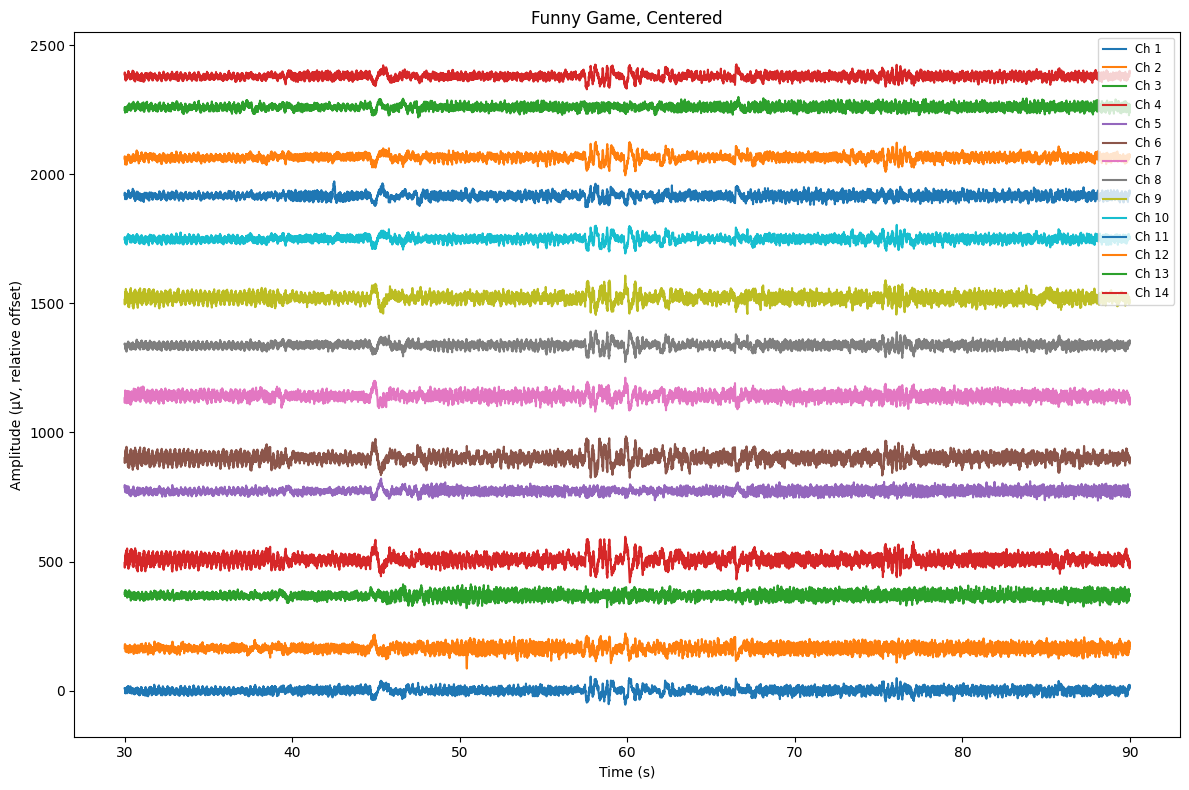

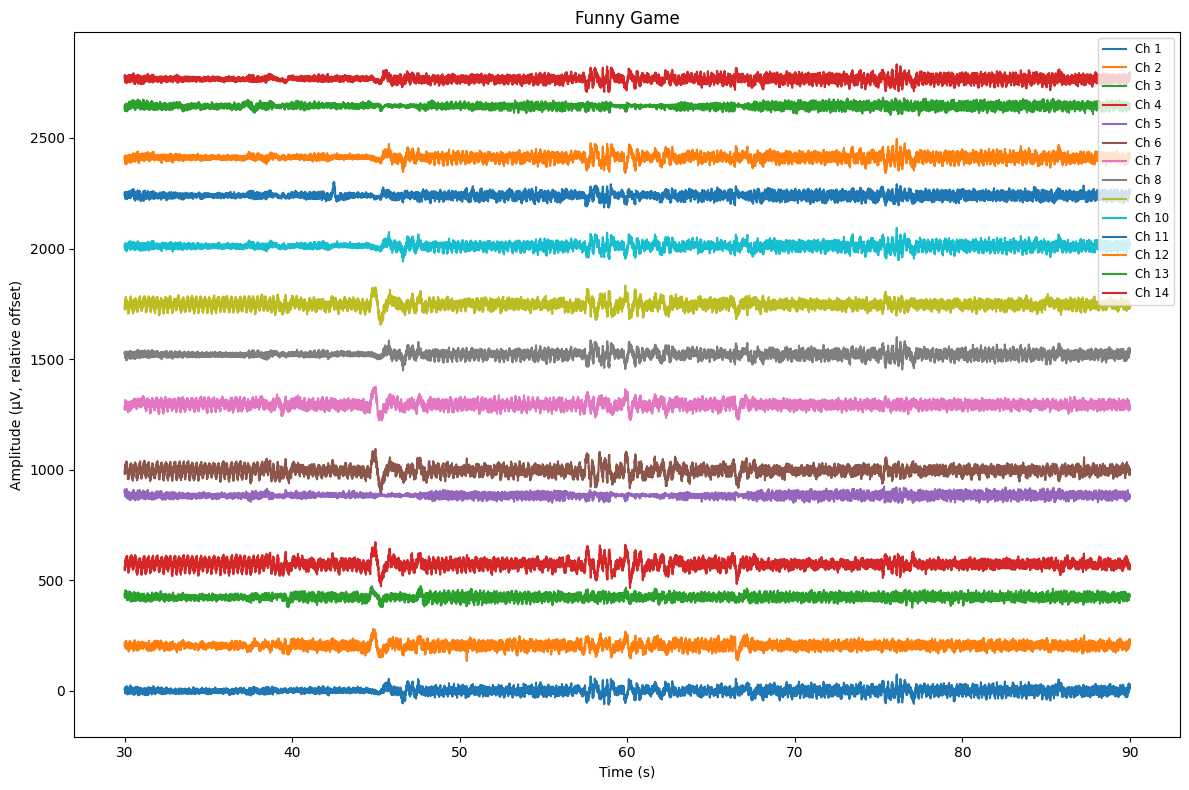

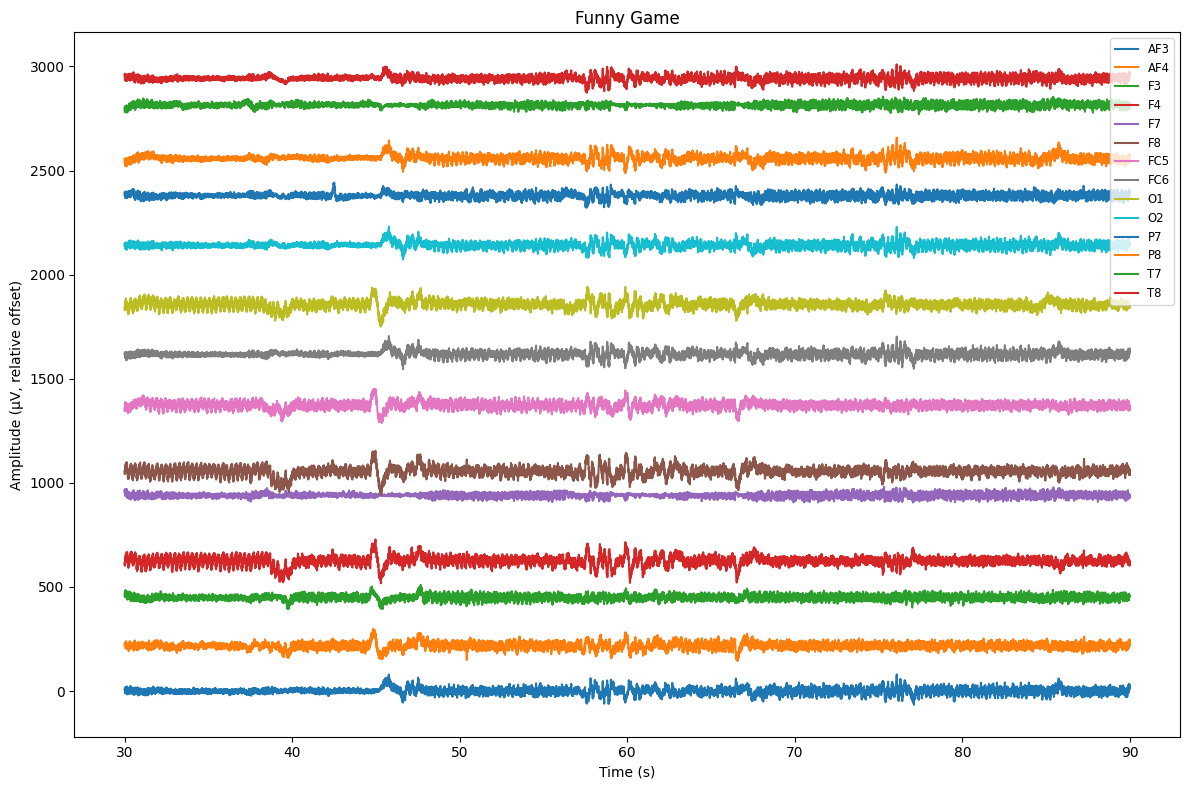

In [26]:
# print(max_eeg_readings(data_array, 12))
duration=60
start=30
plot_eeg_numpy(data_array_centered, 128, duration=duration, start=start, title="Funny Game, Centered")
plot_eeg_numpy(data_array, 128, duration=duration, start=start, title="Funny Game")
channels = list(df.columns)[:-1]
plot_eeg_numpy(df[channels].to_numpy().T, 128, channels, start=start, duration=duration, title="Funny Game")



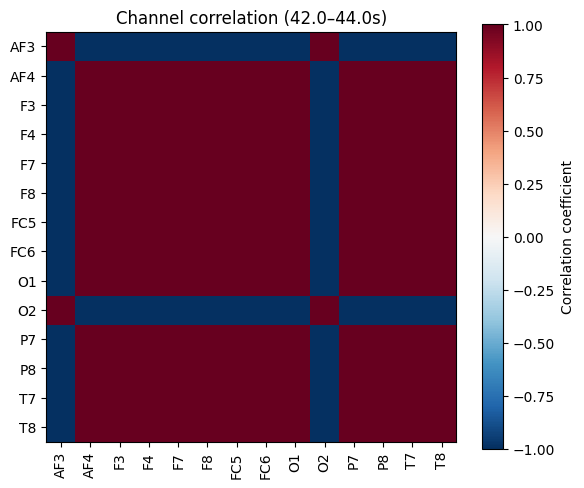

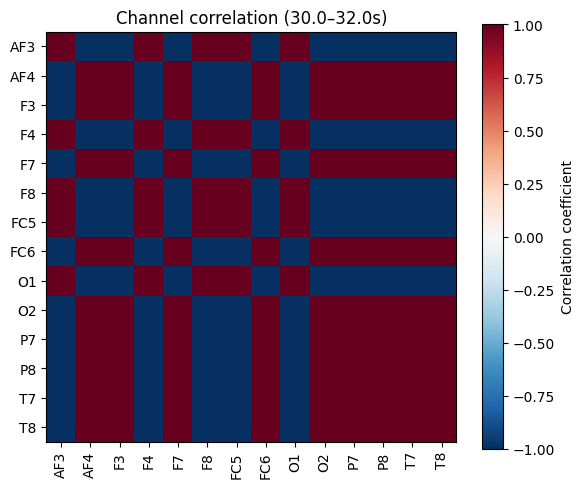

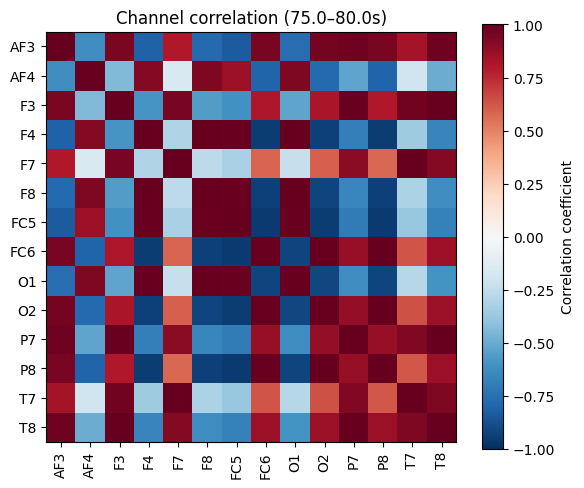

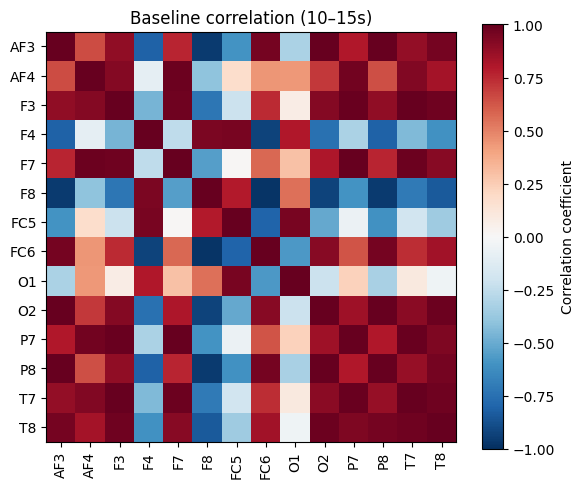

In [29]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Define the suspected artifact periods (in seconds)
# -------------------------------
# Example: three red-circled regions in your image
artifact_windows = [(42, 44), (30, 32), (75, 80)]  # replace with your actual times

# -------------------------------
# 2. Band-pass filter (optional)
# -------------------------------
# Filtering helps remove DC drift for better correlation computation
raw_filt = ica_data.copy().filter(l_freq=1., h_freq=40., fir_design='firwin')

# -------------------------------
# 3. Extract data and compute correlation matrices for each artifact window
# -------------------------------
for start, stop in artifact_windows:
    data, times = raw_filt.get_data(start=start, stop=stop, return_times=True)
    corr_matrix = np.corrcoef(data)
    
    # -------------------------------
    # 4. Visualize the correlation matrix
    # -------------------------------
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_title(f'Channel correlation ({start:.1f}–{stop:.1f}s)')
    ax.set_xticks(range(len(raw.ch_names)))
    ax.set_xticklabels(raw.ch_names, rotation=90)
    ax.set_yticks(range(len(raw.ch_names)))
    ax.set_yticklabels(raw.ch_names)
    plt.colorbar(im, ax=ax, label='Correlation coefficient')
    plt.tight_layout()
    plt.show()

# -------------------------------
# 5. Compare with baseline (non-artifact) periods
# -------------------------------
baseline_window = (10, 15)  # choose a clean region
data_base, _ = raw_filt.get_data(start=baseline_window[0],
                                 stop=baseline_window[1],
                                 return_times=True)
corr_baseline = np.corrcoef(data_base)

plt.figure(figsize=(6, 5))
plt.imshow(corr_baseline, vmin=-1, vmax=1, cmap='RdBu_r')
plt.title(f'Baseline correlation ({baseline_window[0]}–{baseline_window[1]}s)')
plt.xticks(range(len(raw.ch_names)), raw.ch_names, rotation=90)
plt.yticks(range(len(raw.ch_names)), raw.ch_names)
plt.colorbar(label='Correlation coefficient')
plt.tight_layout()
plt.show()


The above heatmaps show High correlations over wide spans of the data uniformly, indicating line noise.   

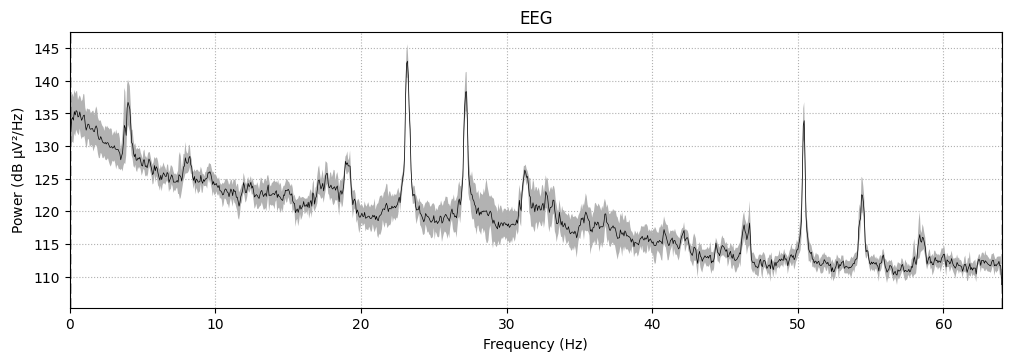

In [30]:
_=spect.plot(
    average=True, amplitude=False
)

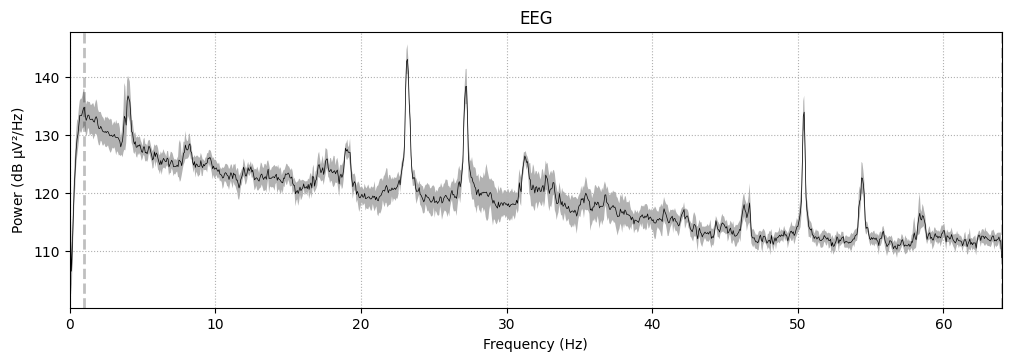

In [31]:
# raw_filtered_low_and_line = raw.notch_filter(freqs=[50, 100, 150], method='spectrum_fit')

spectrum = ica_data.compute_psd()
_=spectrum.plot(
    average=True, amplitude=False
)

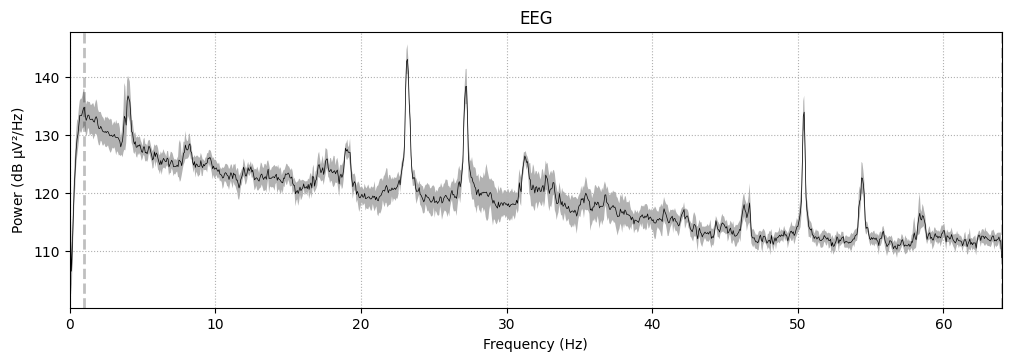

In [35]:
ica_data_centered = ica_data.copy()
data = ica_data.get_data()
data_centered = data - data.mean(axis=1, keepdims=True)
ica_data_centered._data = data_centered

spectrum_centered = ica_data_centered.compute_psd()
_=spectrum_centered.plot(
    average=True, amplitude=False
)

[162.432  157.7999 153.231  152.8723 149.7182 149.1655 148.9428 147.6301
 144.2747 143.4498 142.2013 142.0533]


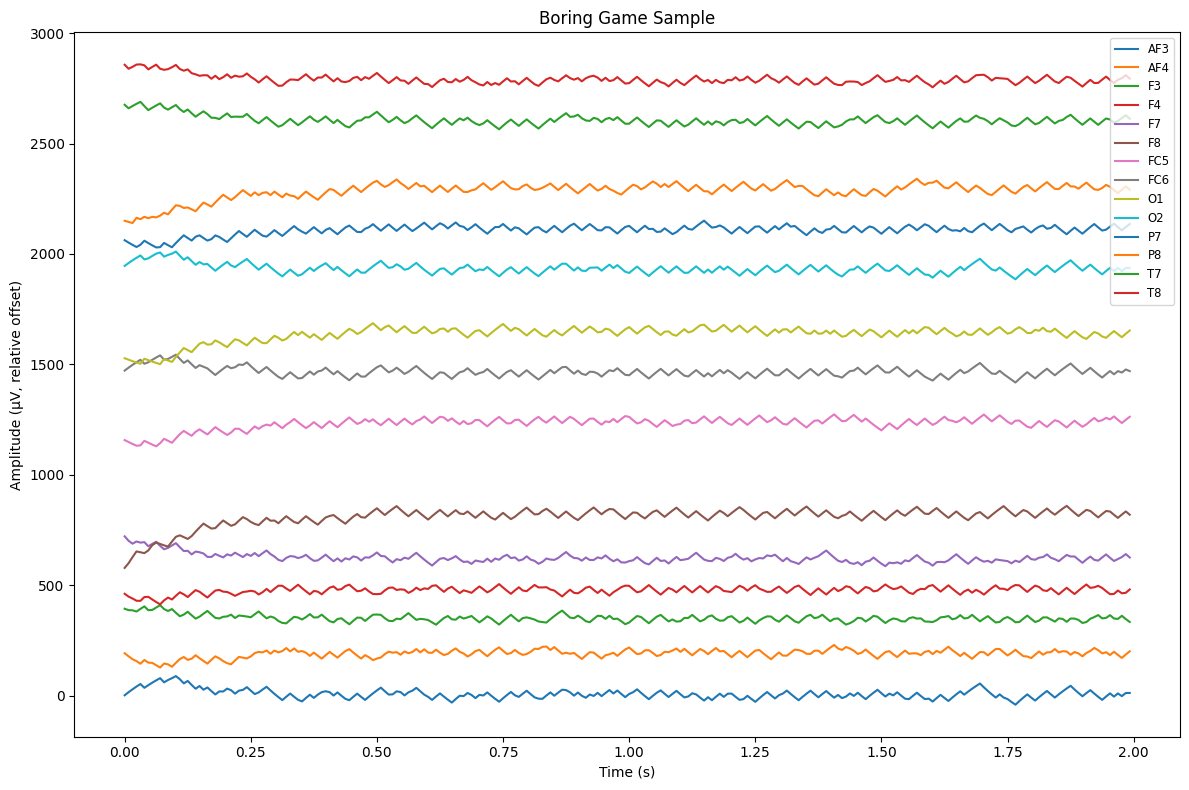

[182.3034 179.8053 178.9397 175.3614 172.0925 171.5547 169.428  168.7181
 165.2425 160.7899 157.2652 156.0531]


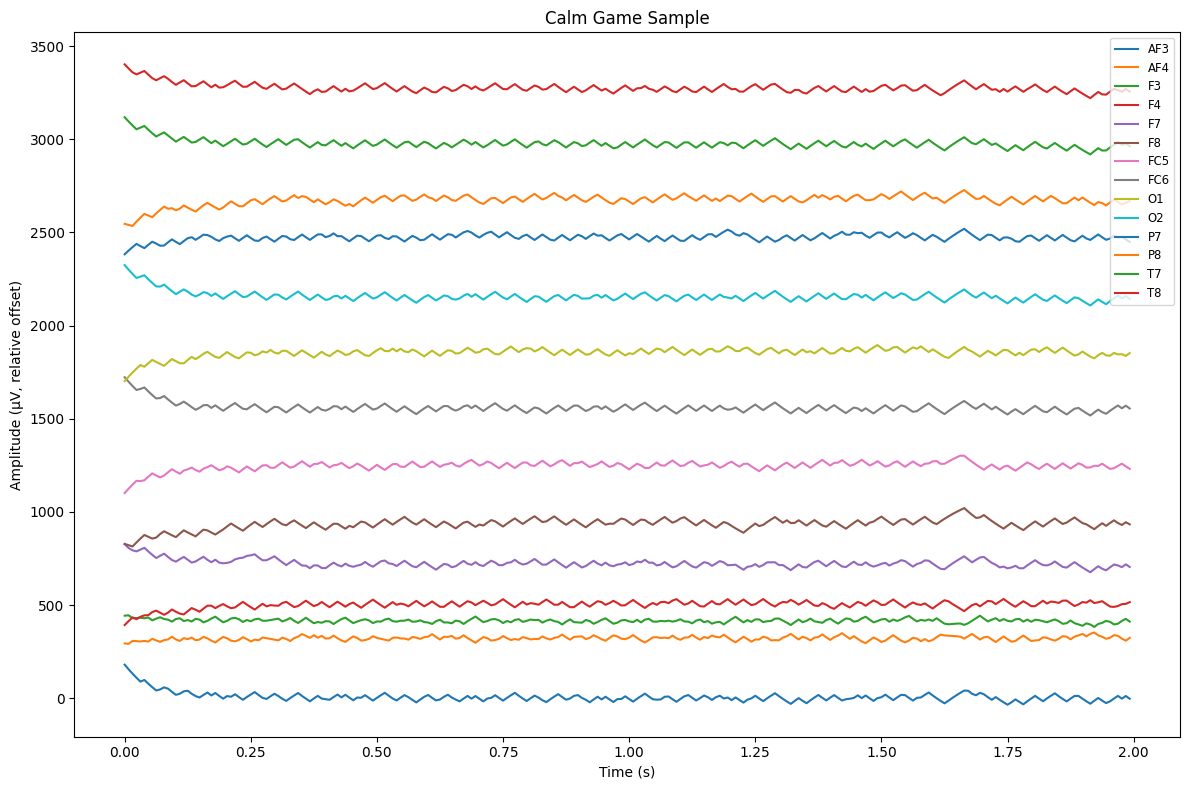

[214.0299 212.6914 211.2674 209.7526 208.141  206.4266 205.4587 204.6828
 204.6028 203.5731 202.6625 201.5671]


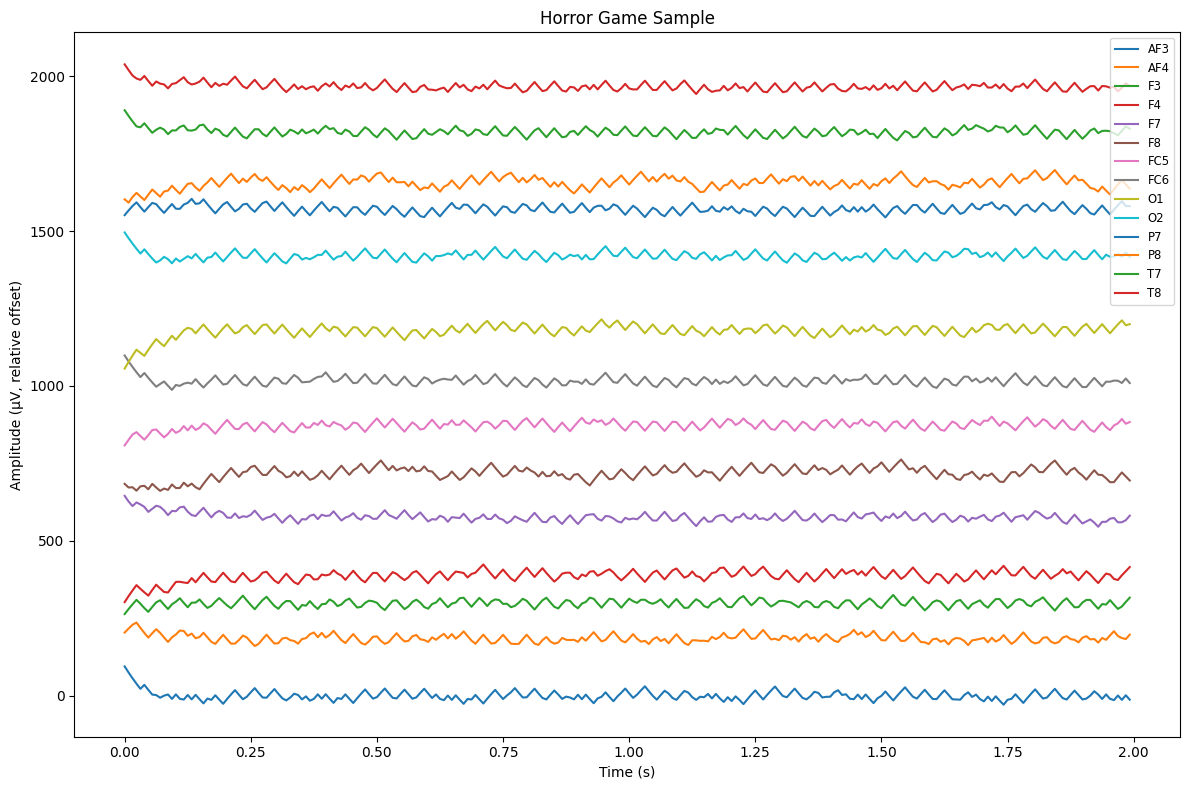

[223.5467 222.8156 222.0379 221.2105 220.8895 220.3303 219.9889 219.3939
 219.0307 218.3978 218.0114 217.3381]


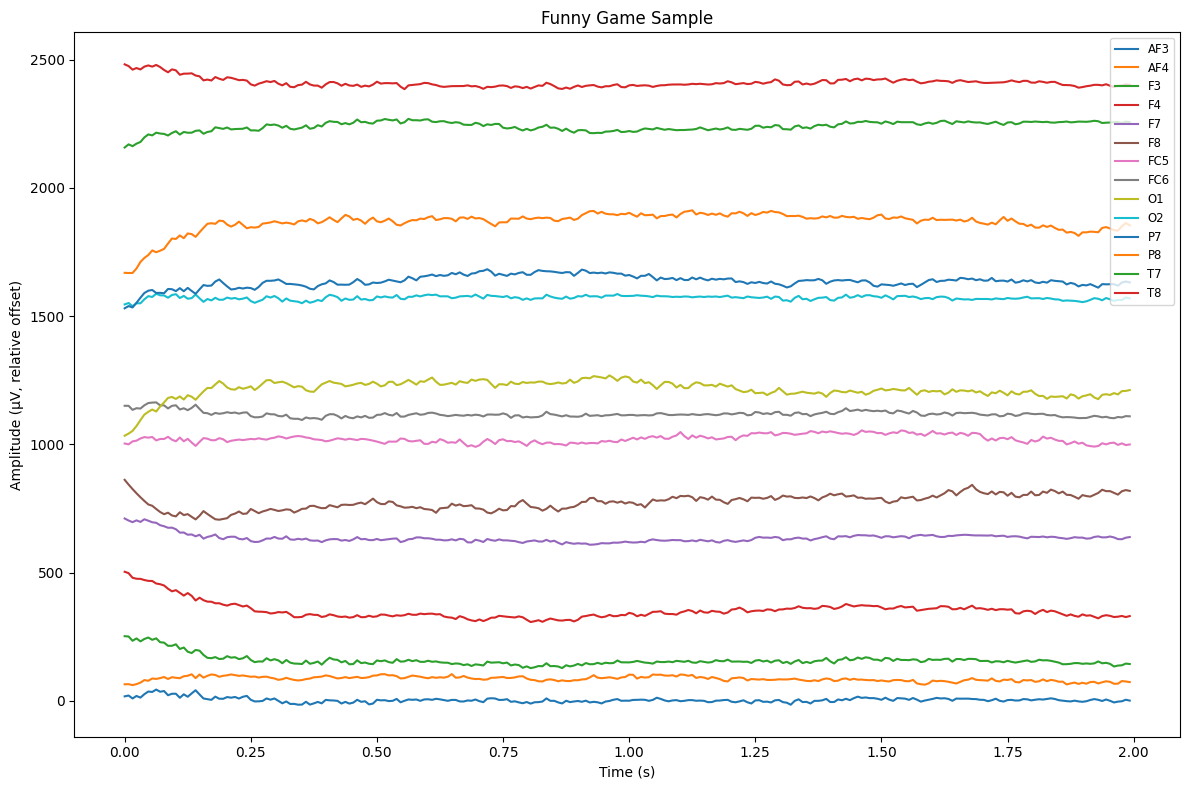

In [62]:
plot_all_subject_data(
    pd.read_csv(r'/kaggle/input/database-for-emotion-recognition-system-gameemo/GAMEEMO/(S03)/Preprocessed EEG Data/.csv format/S03G1AllChannels.csv'),
    pd.read_csv(r'/kaggle/input/database-for-emotion-recognition-system-gameemo/GAMEEMO/(S03)/Preprocessed EEG Data/.csv format/S03G2AllChannels.csv'),
    pd.read_csv(r'/kaggle/input/database-for-emotion-recognition-system-gameemo/GAMEEMO/(S03)/Preprocessed EEG Data/.csv format/S03G3AllChannels.csv'),
    pd.read_csv(r'/kaggle/input/database-for-emotion-recognition-system-gameemo/GAMEEMO/(S03)/Preprocessed EEG Data/.csv format/S03G4AllChannels.csv'),
    duration=2
)

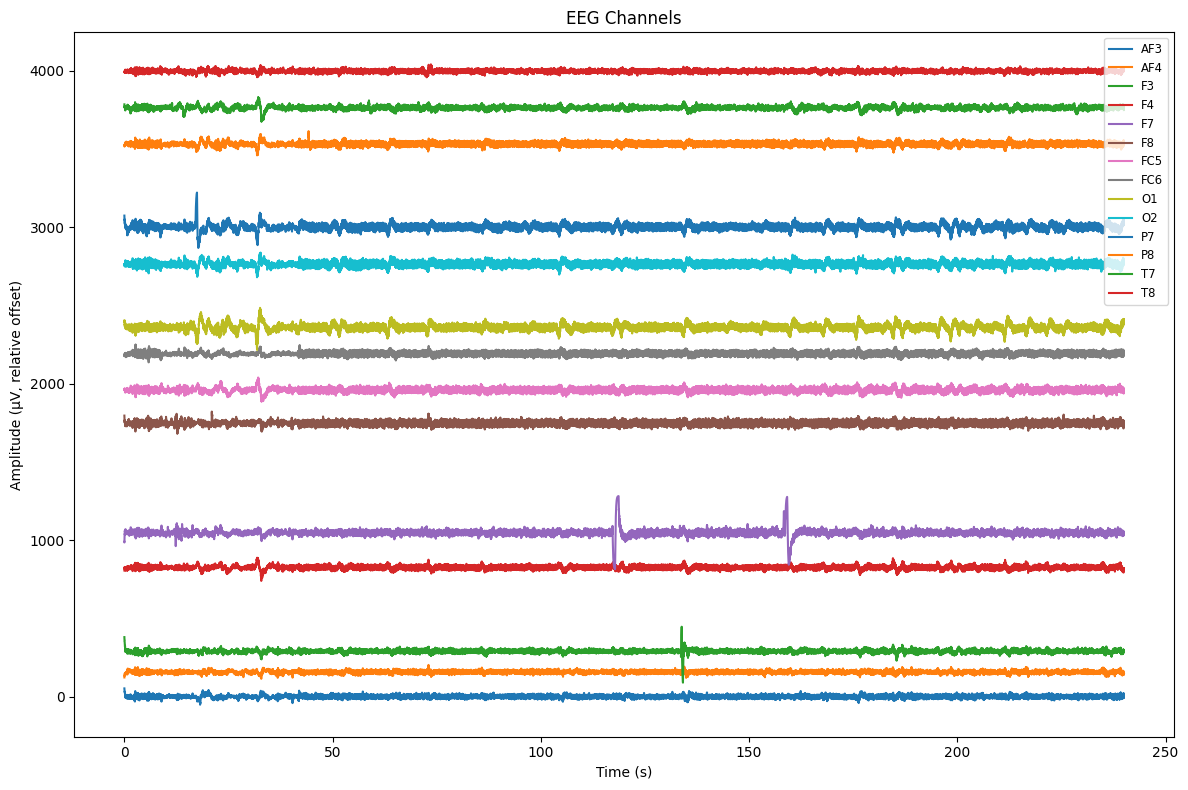

In [21]:
plot_eeg_numpy(df_preprocessed[channels].to_numpy().T, sfreq=128, ch_names=channels, duration=60*4, "sample 1 boring")

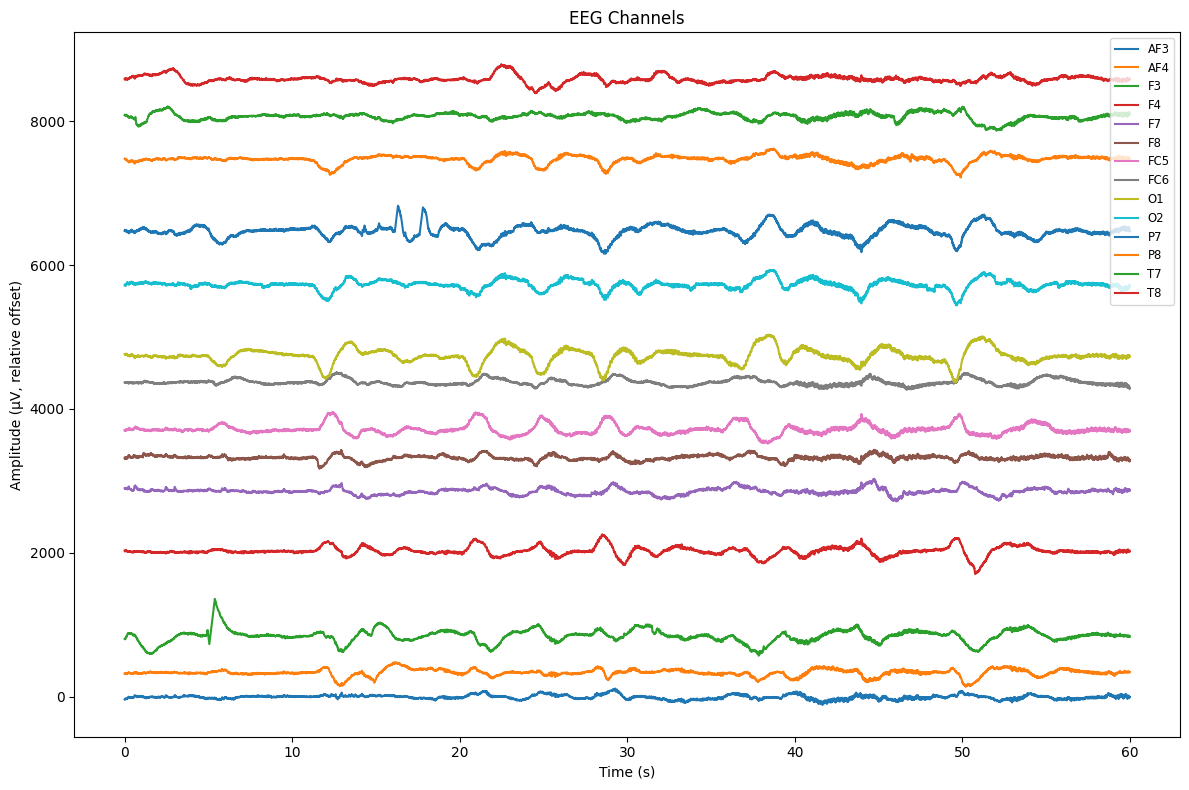

In [41]:
plot_eeg_numpy(df_raw[channels].to_numpy().T, sfreq=128, ch_names=channels, duration=60)

In [14]:
import torch
import torch.nn.functional as F

class STFTSpectrogram:
    """
    Compute an STFT-based spectrogram from EEG or other time-series data.

    Args:
        n_fft (int): FFT window size.
        hop_length (int): Step size between successive frames.
        win_length (int): Window length (default: n_fft).
        window (str): Window type ('hann', 'hamming', etc.).
        power (float): Exponent for the magnitude (1 for magnitude, 2 for power).
        normalized (bool): Whether to normalize the STFT.
        center (bool): Whether to pad input so that the t-th frame is centered.
        return_complex (bool): If True, returns complex STFT output.
    """

    def __init__(self,
                 n_fft=256,
                 hop_length=128,
                 win_length=None,
                 window='hann',
                 power=2.0,
                 normalized=False,
                 center=True,
                 return_complex=False):
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.win_length = win_length or n_fft
        self.power = power
        self.normalized = normalized
        self.center = center
        self.return_complex = return_complex

        # Create the window function
        if window == 'hann':
            self.window = torch.hann_window(self.win_length)
        elif window == 'hamming':
            self.window = torch.hamming_window(self.win_length)
        else:
            raise ValueError(f"Unsupported window type: {window}")

    def __call__(self, eeg: torch.Tensor) -> torch.Tensor:
        """
        Args:
            eeg (torch.Tensor): Input EEG tensor of shape (channels, time)
                                or (time,) for single-channel input.

        Returns:
            torch.Tensor: Spectrogram of shape (channels, freq_bins, time_frames)
        """
        # eeg: torch.Tensor of shape (channels, time)
        eeg = eeg - eeg.mean(dim=0, keepdim=True)
        
        if eeg.dim() == 1:
            eeg = eeg.unsqueeze(0)  # (1, time)

        specs = []
        for ch in eeg:
            stft_out = torch.stft(
                ch,
                n_fft=self.n_fft,
                hop_length=self.hop_length,
                win_length=self.win_length,
                window=self.window.to(ch.device),
                center=self.center,
                normalized=self.normalized,
                return_complex=True,
            )
            if self.return_complex:
                specs.append(stft_out)
            else:
                mag = stft_out.abs().pow(self.power)
                specs.append(mag)

        spectrogram = torch.stack(specs, dim=0)  # (channels, freq_bins, time_frames)
        return spectrogram


In [15]:
from torch.fft import fft

df_preprocessed = df_preprocessed.drop('Unnamed: 14', axis=1)
print(df_preprocessed.shape)

df_raw = df_raw.drop('Unnamed: 14', axis=1)
print(df_raw.shape)

tensor_preprocessed = torch.tensor(df_preprocessed.dropna().to_numpy(dtype=np.float32))
tensor_raw = torch.tensor(df_raw.dropna().to_numpy(dtype=np.float32))

KeyError: "['Unnamed: 14'] not found in axis"

In [8]:
print(type(tensor_preprocessed.T))
print(tensor_preprocessed.T.shape)

<class 'torch.Tensor'>
torch.Size([14, 38252])


In [16]:
from torcheeg.transforms import CWTSpectrum

spectrogram = STFTSpectrogram(
    # n_fft=256,
    # hop_length=128,
    # sampling_rate=128,
    # low_freq=0,
    # high_freq=83,
    # gaussian_sigma=1.0,
    power=1.0
)

tensor_preprocessed_spectrum = spectrogram(eeg=tensor_preprocessed.T)
tensor_raw_spectrum = spectrogram(eeg=tensor_raw.T)

print(tensor_preprocessed_spectrum.shape)
print(tensor_raw_spectrum.shape)

torch.Size([14, 129, 299])
torch.Size([14, 129, 299])


In [17]:
tensor_preprocessed_spectrum

tensor([[[1.1559e+03, 7.2346e+01, 3.7436e+02,  ..., 1.3452e+01,
          4.8363e+01, 1.2379e+02],
         [1.0414e+03, 1.2762e+02, 3.5970e+02,  ..., 5.1386e+01,
          8.0895e+01, 7.3211e+01],
         [8.1849e+02, 3.5964e+01, 1.0233e+02,  ..., 8.0513e+01,
          4.7506e+01, 1.9278e+01],
         ...,
         [1.7521e+00, 2.1194e+00, 7.9789e+00,  ..., 3.7876e+00,
          5.8530e+00, 9.5828e+00],
         [2.4800e+00, 2.4882e+00, 1.3151e+01,  ..., 7.2749e+00,
          1.1228e+01, 1.0744e+01],
         [3.8967e+00, 1.1247e+00, 6.8417e+00,  ..., 8.8576e+00,
          1.0021e+01, 6.9179e+00]],

        [[1.5179e+03, 9.1985e+02, 2.4346e+02,  ..., 9.0291e+01,
          6.3796e+01, 2.7586e+01],
         [1.3322e+03, 8.4153e+02, 2.2116e+02,  ..., 2.4500e+02,
          2.8362e+01, 6.4455e+01],
         [7.8241e+02, 3.8700e+02, 8.0417e+01,  ..., 1.4839e+02,
          1.6102e+02, 9.7563e+01],
         ...,
         [7.7140e+00, 1.5507e+00, 1.0800e+01,  ..., 2.1187e+01,
          1.018

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_eeg_spectrogram_per_channel(
    spectrogram: torch.Tensor,
    channel_names=None,
    title="EEG Spectrogram - ",
    cmap="viridis",
    log_scale=True,
    figsize=(8, 5),
    save_path=None,
):
    """
    Plot EEG spectrograms (e.g., from CWTSpectrum or STFTSpectrogram),
    creating one separate figure per channel.

    Args:
        spectrogram (torch.Tensor or np.ndarray): Tensor of shape 
            (channels, freq_bins, time_frames)
        channel_names (list of str, optional): Names for EEG channels
        title_prefix (str): Prefix for each figure title
        cmap (str): Matplotlib colormap
        log_scale (bool): Whether to apply log scaling (log1p)
        figsize (tuple): Figure size for each plot
        save_path (str, optional): Directory to save plots (if provided)
    """

    # Convert to numpy
    if isinstance(spectrogram, torch.Tensor):
        spec_np = spectrogram.detach().cpu().numpy()
    else:
        spec_np = np.asarray(spectrogram)

    n_channels = spec_np.shape[0]
    channel_names = channel_names or [f"Ch {i+1}" for i in range(n_channels)]

    for i in range(n_channels):
        spec = spec_np[i]
        if log_scale:
            spec = np.log1p(spec)

        plt.figure(figsize=figsize)
        im = plt.imshow(
            spec,
            aspect="auto",
            origin="lower",
            cmap=cmap,
            interpolation="none"
        )
        plt.title(f"{title} {channel_names[i]}")
        plt.xlabel("Time Frame")
        plt.ylabel("Frequency Bin")
        plt.colorbar(im, label="Log Power" if log_scale else "Power")

        plt.tight_layout()

        # Optionally save
        if save_path is not None:
            plt.savefig(f"{save_path}/{channel_names[i]}.png", dpi=150)
            plt.close()
        else:
            plt.show()


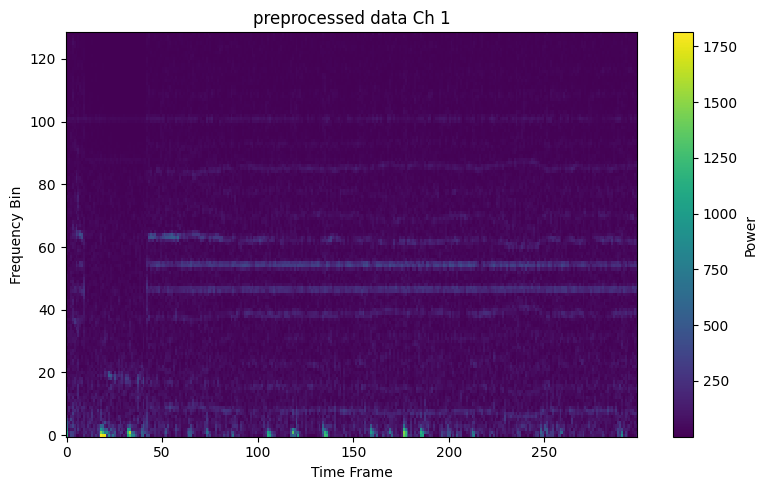

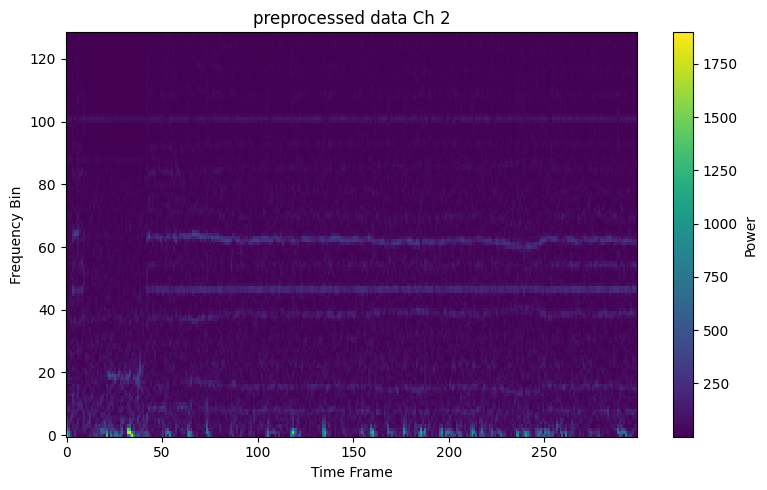

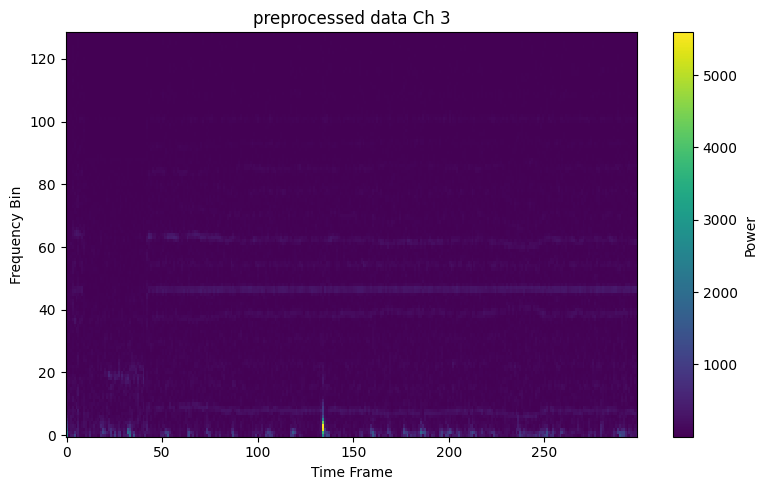

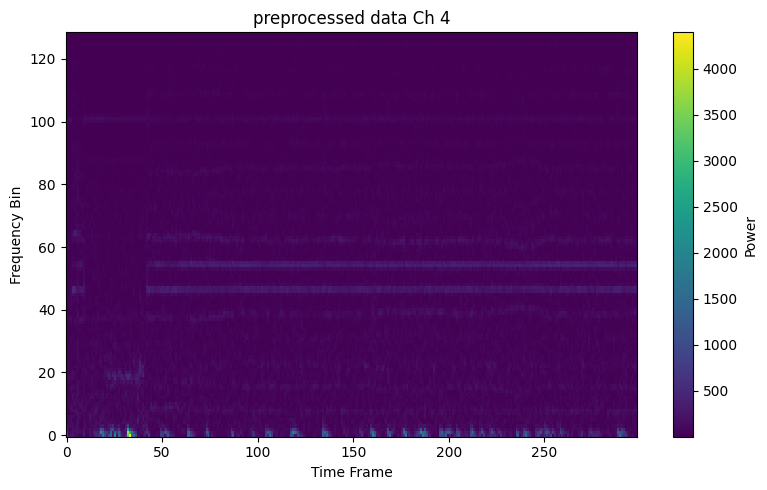

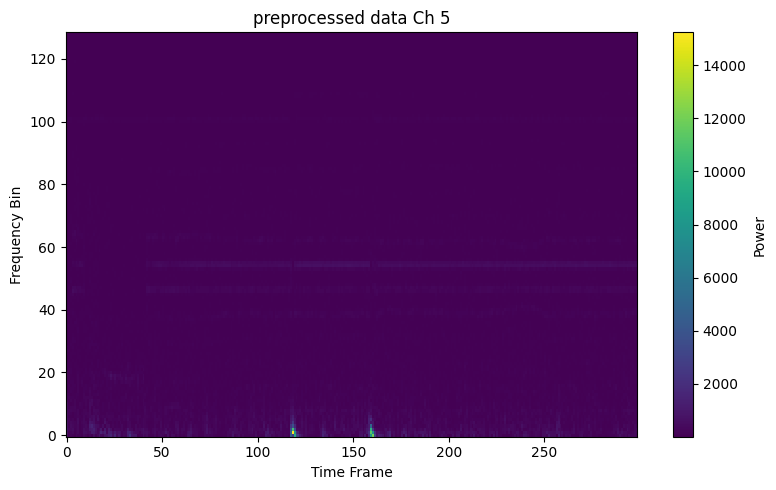

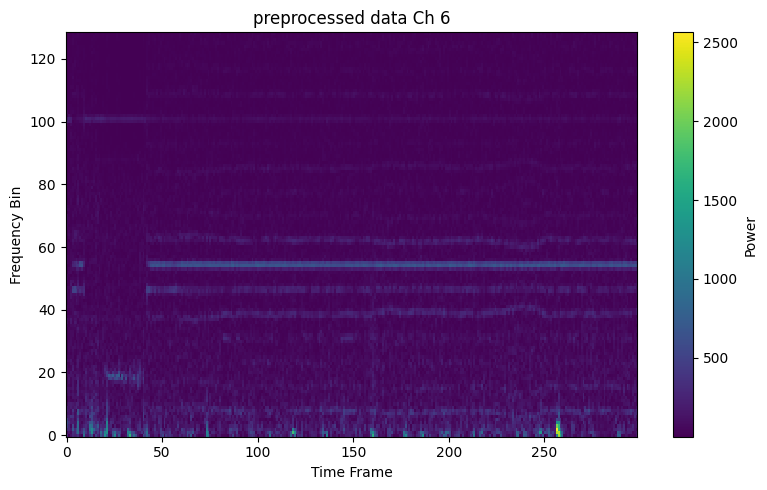

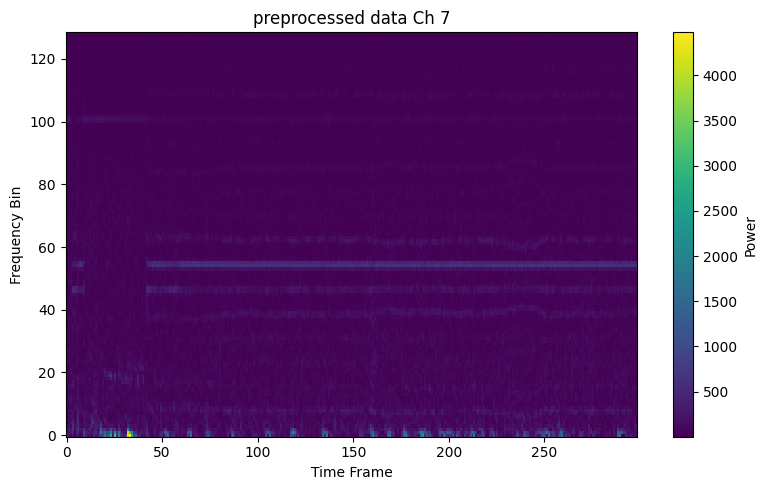

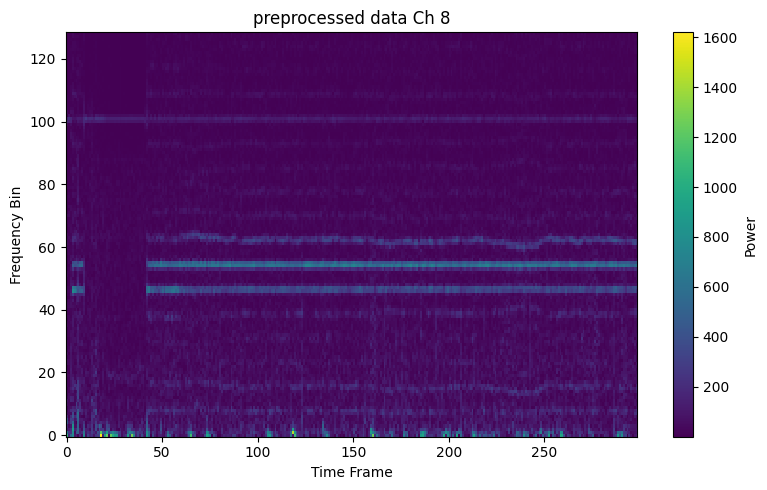

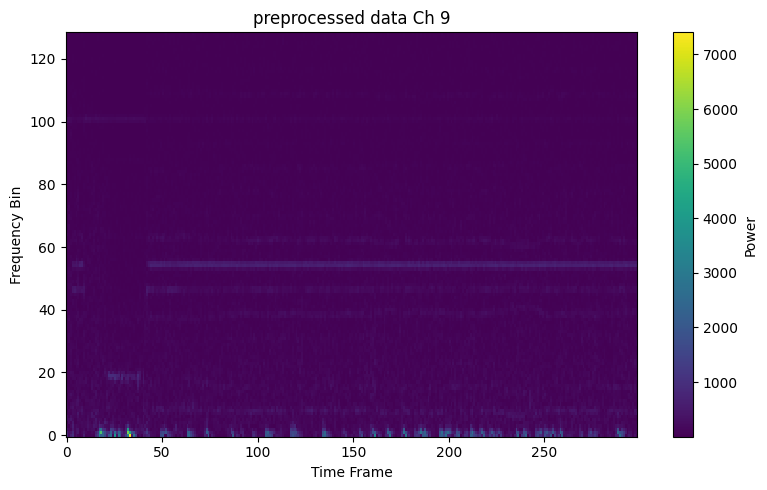

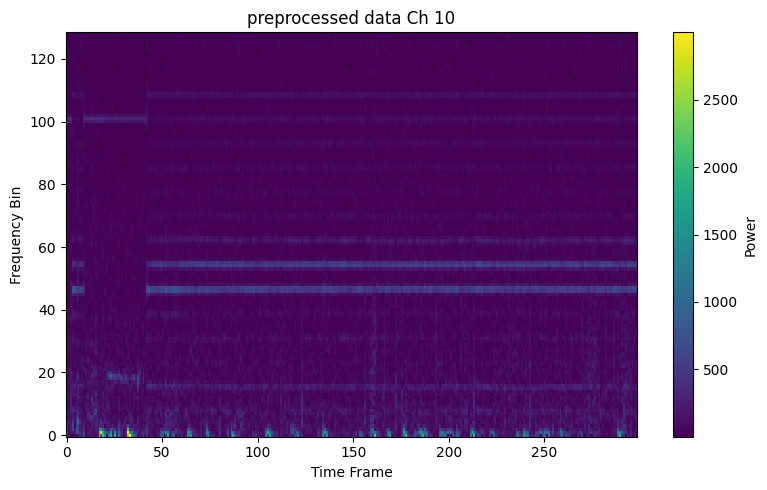

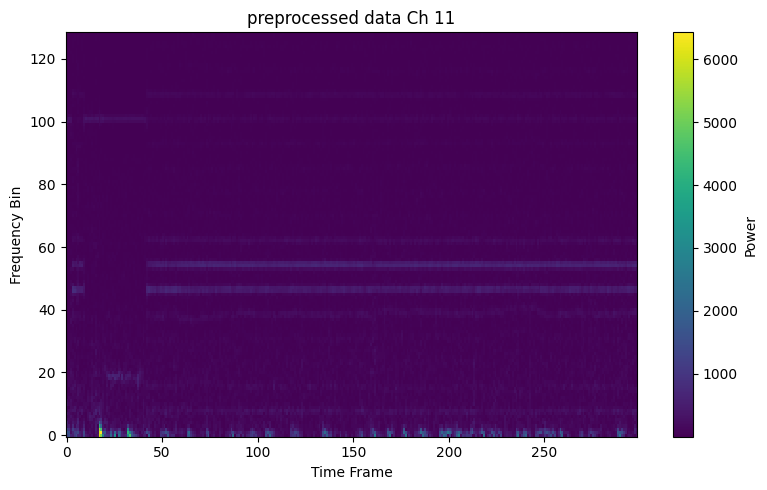

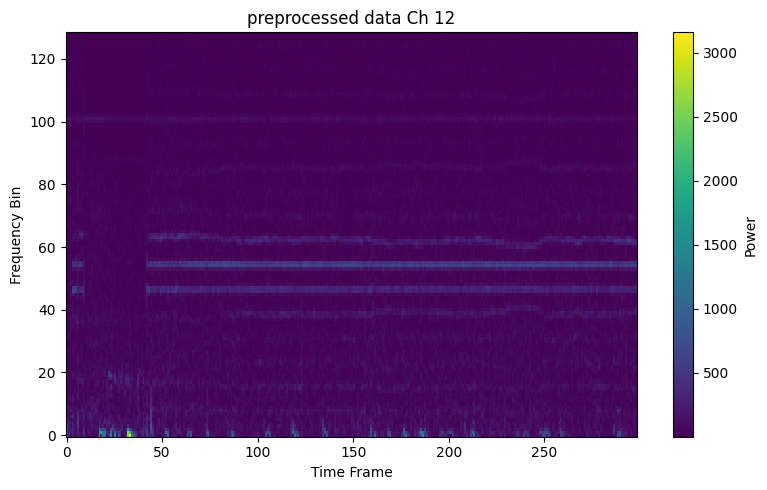

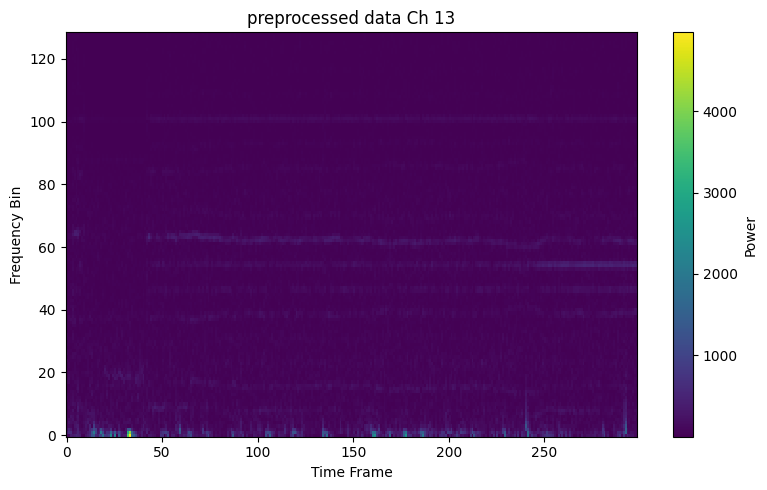

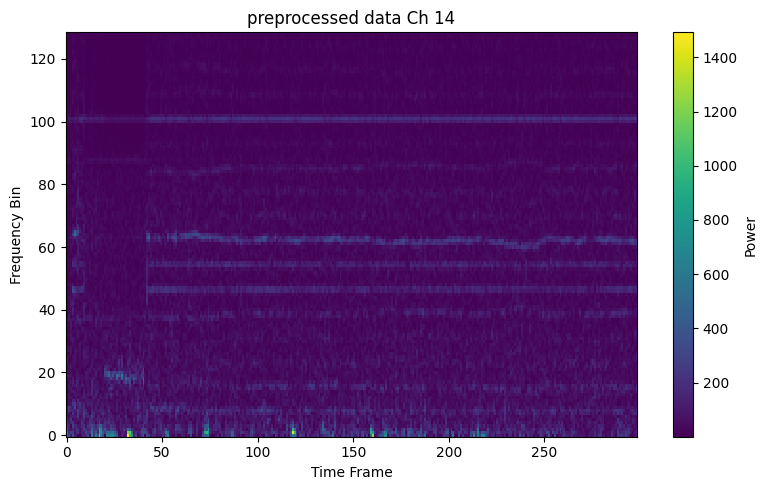

In [19]:
plot_eeg_spectrogram_per_channel(tensor_preprocessed_spectrum, title="preprocessed data", log_scale=False)

In [24]:
from torch.fft import rfft

tensor_fft = rfft(tensor, norm="forward", axis=0)
tensor_fft

tensor([[ 0.0480+0.0000j, -0.0115+0.0000j, -0.0101+0.0000j,  ...,
          0.0656+0.0000j, -0.0147+0.0000j,  0.0154+0.0000j],
        [ 0.0443-0.0949j, -0.0293+0.0099j, -0.0298+0.0140j,  ...,
          0.0403-0.0974j,  0.0349-0.0123j,  0.0339-0.0707j],
        [-0.0356-0.0877j, -0.0071+0.0318j,  0.0013+0.0364j,  ...,
         -0.0405-0.0883j, -0.0028-0.0137j, -0.0283-0.0691j],
        ...,
        [ 0.0252-0.0318j,  0.0069-0.0044j,  0.0210-0.0102j,  ...,
          0.0104-0.0096j, -0.0070+0.0021j,  0.0138-0.0062j],
        [-0.0151-0.0023j,  0.0056-0.0133j,  0.0121+0.0022j,  ...,
         -0.0037+0.0038j, -0.0027-0.0068j,  0.0016+0.0035j],
        [ 0.0393+0.0000j, -0.0054+0.0000j, -0.0078+0.0000j,  ...,
          0.0166+0.0000j,  0.0375+0.0000j,  0.0192+0.0000j]])

In [59]:
tensor_fft.shape

torch.Size([19127, 14])

In [102]:
power_FFT = (torch.abs(rfft(tensor[0].unsqueeze(0), axis=0)) ** 2) / (tensor.shape[0] * 128)
freqs = torch.fft.rfftfreq(tensor.shape[0], 1 / 128)

spectrogram = torch.tensor(power_FFT)
spectrogram

/tmp/ipykernel_37/837133780.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  spectrogram = torch.tensor(power_FFT)


tensor([[5.6386e-04, 2.3255e-04, 1.6953e-03, 7.5936e-05, 6.8342e-04, 4.7459e-04,
         7.5950e-07, 2.5105e-05, 3.6753e-04, 7.5950e-07, 1.1255e-03, 8.0207e-06,
         1.0042e-04, 4.7459e-06]])

In [100]:
spectrogram.T.shape

torch.Size([14, 19127])

In [62]:
srted, _ = torch.sort(spectrogram.reshape(-1), descending=True)[:15]
srted.tolist()

[2058.061279296875,
 2006.9488525390625,
 1948.2392578125,
 1923.26953125,
 1853.32568359375,
 1833.383056640625,
 1635.79443359375,
 1626.4354248046875,
 1524.0673828125,
 1521.14697265625,
 1500.4423828125,
 1403.4168701171875,
 1330.27099609375,
 1305.272216796875,
 1221.2755126953125,
 966.1187744140625,
 884.5751342773438,
 637.6696166992188,
 637.0347290039062,
 575.2578735351562,
 540.63134765625,
 539.3657836914062,
 538.5366821289062,
 530.432861328125,
 519.197998046875,
 515.9732666015625,
 504.9214782714844,
 501.9064025878906,
 499.6811218261719,
 496.20965576171875,
 493.6638488769531,
 476.6935119628906,
 472.9745788574219,
 470.5540771484375,
 465.7504577636719,
 459.6606750488281,
 453.7568664550781,
 452.84320068359375,
 452.1503601074219,
 440.25494384765625,
 438.93145751953125,
 436.51763916015625,
 430.490234375,
 427.315185546875,
 417.29266357421875,
 406.51483154296875,
 404.3514404296875,
 403.4197998046875,
 397.3115234375,
 393.3039855957031,
 385.4399719238

In [84]:
import torch
import matplotlib.pyplot as plt

def plot_overlapping_histograms(tensor, bins=30, alpha=0.4):
    """
    Plots overlapping histograms for each row in a PyTorch tensor.

    Args:
        tensor (torch.Tensor): A tensor with shape (14, N) or (num_rows, N)
        bins (int): Number of histogram bins.
        alpha (float): Transparency level for histogram overlap.
    """
    if not isinstance(tensor, torch.Tensor):
        raise TypeError("Input must be a PyTorch tensor.")
    if tensor.ndim != 2:
        raise ValueError("Tensor must be 2D (e.g., shape (14, N)).")

    num_rows = tensor.shape[0]

    plt.figure(figsize=(10, 6))
    plt.imshow(
        tensor,
        # 10 * np.log10(tensor + 1e-12),   # Convert to dB for better visualization
        aspect='auto',
        origin='lower',
        extent=[0.5, 14.5, freqs[0], freqs[-1]],
        cmap='viridis'
    )
    
    plt.colorbar(label='Power (dB)')
    plt.xlabel('Channel')
    plt.ylabel('Frequency (Hz)')
    plt.title('EEG Power Spectrum per Channel')
    plt.xticks(range(1, 15))
    plt.tight_layout()
    
    plt.show()

# Example usage:
# t = torch.randn(14, 1000)
# plot_overlapping_histograms(t)


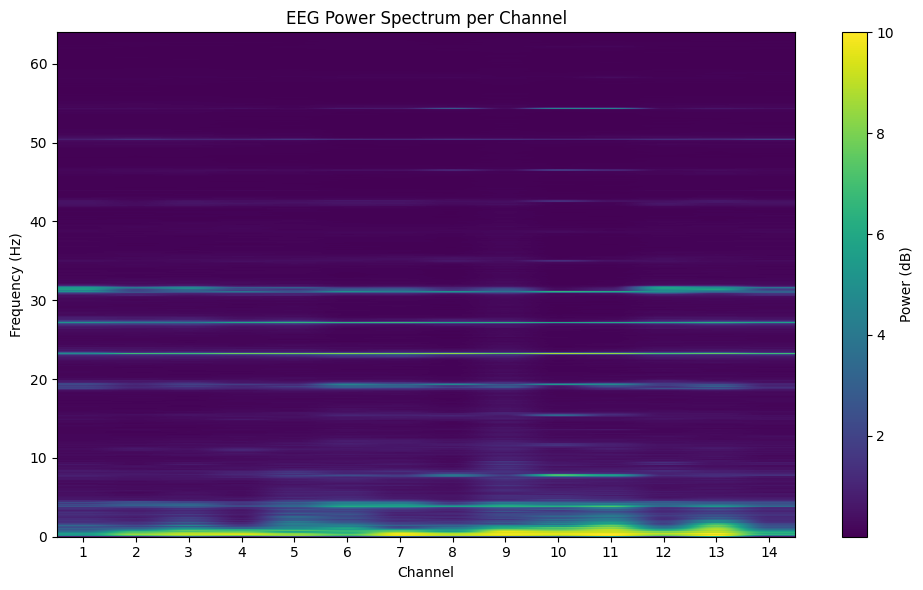

In [90]:
plot_overlapping_histograms(torch.clamp(spectrogram, max=10), bins=100)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assume you already have your EEG data:
# channels.shape = (19000, 14)
# fs = sampling frequency

# Example (if you need dummy data)
# channels = np.random.randn(19000, 14)
# fs = 250  # Hz

# --- FFT computations ---
power_FFT = (np.abs(np.fft.rfft(channels, axis=0)) ** 2) / (channels.shape[0] * fs)
freqs = np.fft.rfftfreq(channels.shape[0], 1 / fs)

# --- Plot ---
plt.figure(figsize=(10, 6))
plt.imshow(
    10 * np.log10(power_FFT + 1e-12),   # Convert to dB for better visualization
    aspect='auto',
    origin='lower',
    extent=[0.5, 14.5, freqs[0], freqs[-1]],
    cmap='viridis'
)

plt.colorbar(label='Power (dB)')
plt.xlabel('Channel')
plt.ylabel('Frequency (Hz)')
plt.title('EEG Power Spectrum per Channel')
plt.xticks(range(1, 15))
plt.tight_layout()
plt.show()

# Data Reshaping Steps
* Assign labels to data properly.
* Divide data based on given sample rate = 128, with an overlap precentage.
* Save last 15% of the data in each file as val and test.
* Concate samples to build train, validation, and test sets.

In [ ]:
class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = decode_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label